In [23]:
import pandas as pd
from tbparse import SummaryReader

# ==========================================
# ZELLE 1: KONFIGURATION & DATEN LADEN
# ==========================================
LOG_DIR = "logs/multiroom_c"  # <-- Hauptordner anpassen

print(f"Lade alle Runs aus dem Ordner '{LOG_DIR}'...")

# Extrahiert die Daten und behält die Run-Namen als 'dir_name'
reader = SummaryReader(LOG_DIR, extra_columns={'dir_name'})
df_all_runs = reader.scalars

# Kontrollausgabe

irrelevant_runs = ["_run_4"]
for run in irrelevant_runs:
    df_all_runs = df_all_runs[df_all_runs["dir_name"] != run]
runs_found = df_all_runs['dir_name'].unique()
print(f"Fertig! Gefundene Runs: {len(runs_found)}")
for run in runs_found:
    print(f" - {run}")

Lade alle Runs aus dem Ordner 'logs/multiroom_c'...
Fertig! Gefundene Runs: 4
 - _run_0
 - _run_1
 - _run_2
 - _run_3


In [24]:
# Welche Environments sollen geplottet werden? 
TASKS_TO_PLOT = ["Uniform"] # <-- Hier beliebig anpassen

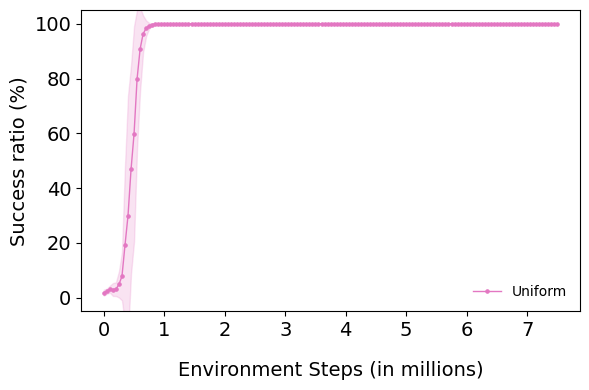

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================
# ZELLE 2: AGGREGIERTER MITTELWERT-PLOT (ALLE RUNS)
# ==========================================
# 1. Konfiguration
SAVE_PATH = "pictures/plots/multiroom/Uniform.jpg"

"Teacher_LP"
"Selected"
"baseline"
METRIC_KEYWORD = "Success ratio %"
"# Selected"
"Success ratio %"
"Teacher_LP"
Y_AXIS_LABEL = "Success ratio" 
"# Selected" 
"Success ratio" 
"Learning Progress" 

STEP_BUCKET_SIZE = 50000

NORMALIZE = True
ENFORCE_BOUNDS = NORMALIZE  
Y_MIN = -5
Y_MAX = 105

# Erweitert um alle neuen Environments aus der Fehlermeldung
TASK_MAPPING = {
    "color": "Color",
    "empty": "Empty",
    "key": "Key",
    "locked_room": "LockedRoom",
    "big_multiroom": "Baseline",
    "multiroom": "Uniform",
    # --- Neue Envs hinzugefügt ---
    "maze_1": "Maze 1",
    "lava_maze_key_locked": "Lava Maze Key Locked",
    "memory_obstacles": "Memory Obstacles",
    "lava_maze_key": "Lava Maze Key",
    "obstacles_1": "Obstacles 1",
    "lava_maze_1": "Lava Maze 1",
    "lava_key_obstacles": "Lava Key Obstacles",
    "lava_2": "Lava 2",
    "easy_memory": "Easy Memory",
    "lava_1": "Lava 1",
    "lava_0": "Lava 0",
    "lava_maze_0": "Lava Maze 0",
    "lava_goal": "Lava Goal"
}

# Deine 6 alten Farben bleiben EXAKT gleich.
# Die 13 neuen Envs haben jetzt alle eine eigene, unterscheidbare Farbe bekommen.
TASK_COLORS = {
    "Color": "tab:blue",
    "Empty": "tab:orange",
    "Key": "tab:green",
    "LockedRoom": "tab:red",
    "Baseline": "tab:grey",
    "Uniform": "tab:pink",
    "LP": "tab:blue",
    # --- Neue unterscheidbare Farben ---
    "Maze 1": "tab:pink",
    "Lava Maze Key Locked": "tab:gray",
    "Memory Obstacles": "tab:olive",
    "Lava Maze Key": "tab:cyan",
    "Obstacles 1": "#1abc9c",       # Türkis
    "Lava Maze 1": "#2c3e50",       # Dunkelblau/Grau
    "Lava Key Obstacles": "#d35400",  # Dunkelorange
    "Lava 2": "#7f8c8d",            # Aschgrau
    "Easy Memory": "#f1c40f",       # Gelb
    "Lava 1": "#27ae60",            # Dunkelgrün
    "Lava 0": "#2980b9",            # Ozeanblau
    "Lava Maze 0": "#8e44ad",       # Dunkelviolett
    "Lava Goal": "#e74c3c"          # Hellrot
}
# 2. Daten filtern & umbenennen (Das bleibt, weil es saubere Vorarbeit ist)
df_metrics = df_all_runs[df_all_runs['tag'].str.contains(METRIC_KEYWORD)].copy()
df_metrics['Task'] = df_metrics['tag'].apply(lambda x: x.split('/')[-1] if '/' in x else x)
df_metrics['Task'] = df_metrics['Task'].replace(TASK_MAPPING)

df_plot = df_metrics[df_metrics['Task'].isin(TASKS_TO_PLOT)]

if NORMALIZE:
    df_plot['value'] = df_plot['value'] * 100

# 3. DIE AUFGERÄUMTE DATENVERARBEITUNG
# Wir werfen die Schritte in "Eimer" (Buckets) und mitteln sie direkt. 
# Das glättet die Kurve UND macht sie für Seaborn lesbar in nur 2 Zeilen.
df_plot['step'] = (df_plot['step'] // STEP_BUCKET_SIZE) * STEP_BUCKET_SIZE
df_clean = df_plot.groupby(['Task', 'dir_name', 'step'], as_index=False)['value'].mean()

# 4. Plotten
plt.figure(figsize=(6, 4)) 
sns.lineplot(
    data=df_clean, 
    x='step', 
    y='value', 
    hue='Task', 
    palette=TASK_COLORS, # <--- NEU: Zwingt Seaborn, exakt diese Farben zu nutzen!
    estimator='mean',  
    errorbar='sd',     
    linewidth=1,
    marker='o',        
    markersize=2.5,      
    markeredgecolor=None 
)

# 5. Styling
plt.xlabel("Environment Steps (in millions)", fontsize=14, labelpad=15)
plt.ylabel(f"{Y_AXIS_LABEL} (%)" if NORMALIZE else Y_AXIS_LABEL, fontsize=14)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

if ENFORCE_BOUNDS:
    plt.ylim(Y_MIN, Y_MAX)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(SAVE_PATH, format="jpg", bbox_inches="tight")
plt.show()

Lade Runs aus mehreren Ordnern...
Fertig! Gesamte Datenpunkte: 520544


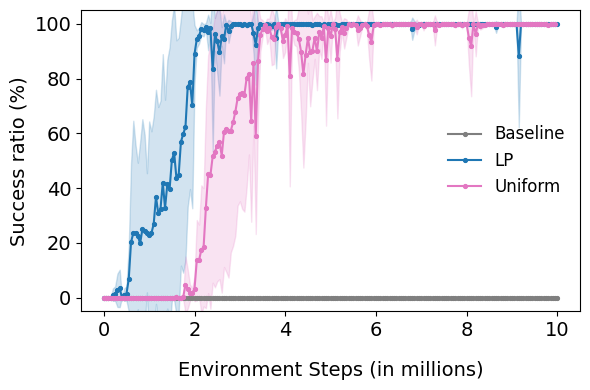

In [26]:
import pandas as pd
from tbparse import SummaryReader
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==========================================
# ZELLE 1: KONFIGURATION & MEHRERE DATEN LADEN
# ==========================================
# Dictionary mit Name der Methode -> Pfad zum Ordner
LOG_DIRS = {
    "LP": "logs/locked_c",      # <-- Deine Methode (Pfad anpassen)
    "Uniform": "logs/locked_c_random",     # <-- Random Baseline
    "Baseline": "logs/locked_b"          # <-- Normale Baseline
}



NORMALIZE = True
ENFORCE_BOUNDS = NORMALIZE  

SAVE_PATH = "pictures/plots/key/comparison.jpg"
METRIC_KEYWORD = "Success ratio"  # <-- Hier wollen wir nur die SR vergleichen
Y_AXIS_LABEL = "Success ratio"
TARGET_TASK = "LockedRoom"               # <-- Nur das Target Env!

print("Lade Runs aus mehreren Ordnern...")

df_list = []
irrelevant_runs = []

for method_name, folder_path in LOG_DIRS.items():
    reader = SummaryReader(folder_path, extra_columns={'dir_name'})
    df_temp = reader.scalars
    
    # Filtern
    for run in irrelevant_runs:
        df_temp = df_temp[df_temp["dir_name"] != run]
        
    # Neue Spalte für die Methode hinzufügen!
    df_temp['Method'] = method_name
    df_list.append(df_temp)

# Alles zu einem großen DataFrame zusammenfügen
df_all_runs = pd.concat(df_list, ignore_index=True)

print(f"Fertig! Gesamte Datenpunkte: {len(df_all_runs)}")

# ==========================================
# ZELLE 2: TARGET ENV COMPARISON PLOT
# ==========================================



# 1. Daten filtern
df_metrics = df_all_runs[df_all_runs['tag'].str.contains(METRIC_KEYWORD, case=False, na=False)].copy()
df_metrics['Task'] = df_metrics['tag'].apply(lambda x: x.split('/')[-1] if '/' in x else x)


df_metrics['Task'] = df_metrics['Task'].replace(TASK_MAPPING)

# NUR das Target Environment behalten!
df_plot = df_metrics[df_metrics['Task'] == TARGET_TASK].copy()

if NORMALIZE:
    df_plot['value'] = df_plot['value'] * 100

# 2. Bucketing (Dein exakter Code)
df_plot['step'] = (df_plot['step'] // STEP_BUCKET_SIZE) * STEP_BUCKET_SIZE
df_clean = df_plot.groupby(['Method', 'dir_name', 'step'], as_index=False)['value'].mean()

# Eigene Farben für die Methoden definieren
METHOD_COLORS = {
    "LP": "tab:blue",
    "Uniform": "tab:pink",
    "Baseline": "tab:gray"
}

# 3. Plotten
plt.figure(figsize=(6, 4)) 
sns.lineplot(
    data=df_clean, 
    x='step', 
    y='value', 
    hue='Method',          # <--- WICHTIG: Jetzt wird nach Methode gefärbt!
    palette=METHOD_COLORS, # <--- WICHTIG: Methoden-Farben!
    estimator='mean',  
    errorbar='sd',     
    linewidth=1.5,
    marker='o',        
    markersize=3,      
    markeredgecolor=None 
)

# 4. Styling (Exakt dein Code)
plt.xlabel("Environment Steps (in millions)", fontsize=14, labelpad=15)
plt.ylabel(f"{Y_AXIS_LABEL} (%)" if NORMALIZE else Y_AXIS_LABEL, fontsize=14)
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1e6:g}'))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

if ENFORCE_BOUNDS:
    plt.ylim(Y_MIN, Y_MAX)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig(SAVE_PATH, format="jpg", bbox_inches="tight", dpi=300)
plt.show()

In [4]:
CURRICULUM = ["empty", "multiroom", "key", "locked_room", "easy_memory", "lava_0", "lava_1", "lava_2", "lava_maze_0",
 "lava_maze_1", "maze_1", "lava_goal", "lava_maze_key","lava_maze_key_locked", "obstacles_1", "lava_key_obstacles", "memory_obstacles"]
CURRICULUM.sort()

In [ ]:
CURRICULUM_GROUPS = {
    "Basics": ["empty", "key", "multiroom"],
    "Lava": ["lava_0", "lava_1", "lava_2", "lava_maze_0", "lava_maze_1"],
    "Intermediate": ["locked_room", "easy_memory", "maze_1", "obstacles_1"],
    "Advanced": ["lava_goal", "memory_obstacles", "lava_maze_key", "lava_maze_key_locked", "lava_key_obstacles" ]
}


test = []
for v in CURRICULUM_GROUPS.values():
    test += v
test.sort()
assert(test == CURRICULUM)